## US Car Accidents - Severity Prediction

---

## Context and Motivation

Traffic accidents are one of the most significant public safety challenges in the United States, costing hundreds of billions of dollars every year in economic and societal impact. A large share of these costs is driven by a relatively small number of high-severity accidents.

The **proactive approach** to road safety aims to prevent potentially unsafe conditions before they occur. To implement it effectively, it is essential to be able to **predict the likelihood and severity** of an accident from contextual variables (weather, infrastructure, time, geographic location), without requiring detailed information about the accident itself or the vehicles involved.

The provided dataset contains approximately 7.7 million accident records collected across 49 US states.

---

## Project Objectives

1. **Predictive modeling:** build a model capable of predicting the severity of an accident (`Severity`) from the features available at the time of the event. The candidate may choose whether to predict the full severity index or focus specifically on identifying critical-severity accidents (severity equal to 4).
2. **Key factor identification:** determine which variables most strongly influence accident severity and communicate the findings clearly.

---

## Dataset Schema

The CSV file contains **47 columns**. The full attribute descriptions are listed below:

### Identification and Target

| # | Column | Description |
|---|--------|-------------|
| 1 | `ID` | Unique identifier for the accident record. |
| 2 | `Severity` | **Target variable.** Accident severity on a scale of 1–4: `1` = minimal traffic impact, `4` = significant traffic impact (long delay). |

### Time

| # | Column | Description |
|---|--------|-------------|
| 3 | `Start_Time` | Start date and time of the accident (local timezone). |
| 4 | `End_Time` | Date and time when the traffic impact was cleared (local timezone). |

### Geographic Location

| # | Column | Description |
|---|--------|-------------|
| 5 | `Start_Lat` | GPS latitude of the start point. |
| 6 | `Start_Lng` | GPS longitude of the start point. |
| 7 | `End_Lat` | GPS latitude of the end point. |
| 8 | `End_Lng` | GPS longitude of the end point. |
| 9 | `Distance(mi)` | Length of the road segment affected by the accident (miles). |
| 11 | `Number` | Street number in the address. |
| 12 | `Street` | Street name. |
| 13 | `Side` | Relative side of the street (Right/Left). |
| 14 | `City` | City. |
| 15 | `County` | County. |
| 16 | `State` | State. |
| 17 | `Zipcode` | ZIP code. |
| 18 | `Country` | Country. |
| 19 | `Timezone` | Timezone based on accident location (Eastern, Central, Mountain, Pacific). |
| 20 | `Airport_Code` | Code of the nearest airport-based weather station. |

### Weather Conditions

| # | Column | Description |
|---|--------|-------------|
| 21 | `Weather_Timestamp` | Timestamp of the weather observation associated with the accident. |
| 22 | `Temperature(F)` | Temperature in Fahrenheit. |
| 23 | `Wind_Chill(F)` | Perceived temperature (wind chill) in Fahrenheit. |
| 24 | `Humidity(%)` | Relative humidity (%). |
| 25 | `Pressure(in)` | Air pressure (inches). |
| 26 | `Visibility(mi)` | Visibility in miles. |
| 27 | `Wind_Direction` | Wind direction. |
| 28 | `Wind_Speed(mph)` | Wind speed (mph). |
| 29 | `Precipitation(in)` | Precipitation amount in inches, if any. |
| 30 | `Weather_Condition` | General weather condition (rain, snow, fog, thunderstorm, etc.). |

### Points of Interest (POI) — Road Infrastructure

All of the following columns are boolean and indicate the **presence of a nearby infrastructure element** at the accident location.

| # | Column | Description |
|---|--------|-------------|
| 31 | `Amenity` | Presence of a nearby amenity. |
| 32 | `Bump` | Presence of a speed bump or hump. |
| 33 | `Crossing` | Presence of a pedestrian crossing. |
| 34 | `Give_Way` | Presence of a give-way sign. |
| 35 | `Junction` | Presence of a junction. |
| 36 | `No_Exit` | Presence of a no-exit sign. |
| 37 | `Railway` | Presence of a railway. |
| 38 | `Roundabout` | Presence of a roundabout. |
| 39 | `Station` | Presence of a station (bus, train, etc.). |
| 40 | `Stop` | Presence of a stop sign. |
| 41 | `Traffic_Calming` | Presence of traffic calming measures. |
| 42 | `Traffic_Signal` | Presence of a traffic signal. |
| 43 | `Turning_Loop` | Presence of a turning loop. |

### Light Conditions

| # | Column | Description |
|---|--------|-------------|
| 44 | `Sunrise_Sunset` | Period of day (Day/Night) based on sunrise/sunset. |
| 45 | `Civil_Twilight` | Period of day based on civil twilight. |
| 46 | `Nautical_Twilight` | Period of day based on nautical twilight. |
| 47 | `Astronomical_Twilight` | Period of day based on astronomical twilight. |

### Free Text

| # | Column | Description |
|---|--------|-------------|
| 10 | `Description` | Natural language description of the accident. |

---

## Deliverables

The candidate is free to structure the work as they see fit. At the end of the project, they should be able to answer the following three questions:

1. **What model did you train and what performance do you achieve** in predicting accident severity?
2. **What are the most important factors** influencing accident severity according to your model? Can you explain why?
3. **What operations did you perform on the dataset? What challenges did you encounter** and how did you address them?

**Deliverable:** a public GitHub repository containing the code and at least one document describing the process followed and the results obtained (notebook, report, or any other format deemed appropriate).
The candidate will be asked to present and discuss their work during the interview.

---

## Practical Notes

- The full dataset is very large. If you are not able to load to complete file, you can also work on the reduced version (1M sampled rows).
- Complete freedom in the choice of programming language and algorithmic approaches.
- Perfect results are not expected: what matters is clarity of reasoning, quality of analysis, and the ability to communicate decisions effectively.


## Configuration

In [17]:
from pathlib import Path

PARQUET_PATH = Path("/Users/daniel_dalascio/Downloads/US_accidents_dataset.parquet")  # e.g.: Path("/path/to/your_file.parquet")
N_SAMPLE = 1_000_000  # or None to use all

# test horizon
TEST_DAYS = 90

RANDOM_STATE = 42

## 1) Imports and Environment Verification
- We use `pandas` + `pyarrow`/`fastparquet` to read Parquet
- `scikit-learn` for pipeline, encoding, and model
- `matplotlib` for plots

In [18]:
import sys, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, classification_report, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

plt.style.use("seaborn-v0_8") if "seaborn-v0_8" in plt.style.available else None

print("Versions:")
print("python:", sys.version.split(" ")[0])
print("pandas:", pd.__version__)
try:
    import pyarrow
    print("pyarrow:", pyarrow.__version__)
except Exception:
    print("pyarrow: not available")
try:
    import fastparquet
    print("fastparquet:", fastparquet.__version__)
except Exception:
    print("fastparquet: not available")

Versions:
python: 3.12.6
pandas: 2.3.3
pyarrow: 23.0.1
fastparquet: 2025.12.0


## 2) Select Columns **Valid at t0** (Avoid Leakage)
Exclude `End_Time`, `End_*`, `Distance(mi)` and keep weather observation only if `Weather_Timestamp ≤ Start_Time`.

In [19]:
USECOLS = [
    # Identification and Target
    "ID","Severity",
    # Time
    "Start_Time",
    # Geographic Location
    "Start_Lat","Start_Lng","City","County","State","Zipcode","Timezone",
    # Weather Conditions
    "Weather_Timestamp","Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)",
    "Visibility(mi)","Wind_Direction","Wind_Speed(mph)","Precipitation(in)","Weather_Condition",
    # Points of Interest (POI) — Road Infrastructure
    "Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout",
    "Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop",
    # Light Conditions
    "Sunrise_Sunset","Civil_Twilight","Nautical_Twilight","Astronomical_Twilight",
]
print("Selected columns (", len(USECOLS), "):", USECOLS)

Selected columns ( 37 ): ['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## 3) Load Parquet (Selected Columns Only)
If the file is very large, you can start with `N_SAMPLE` to iterate quickly.

In [20]:
# check file path before reading
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Parquet file not found: {PARQUET_PATH}")

# load data
print(f"reading parquet from {PARQUET_PATH} (N_SAMPLE={N_SAMPLE})")
df = pd.read_parquet(PARQUET_PATH, columns=USECOLS)
print("columns read:", df.columns.tolist())

# Convert to datetime
for c in ["Start_Time","Weather_Timestamp"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# report initial missing values
print("missing by column (before weather filter):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Filter weather: keep only observations <= Start_Time or NA
if "Weather_Timestamp" in df.columns and "Start_Time" in df.columns:
    mask_ok = df["Weather_Timestamp"].isna() | (df["Weather_Timestamp"] <= df["Start_Time"])
    df = df.loc[mask_ok].copy()
    print("shape after weather filter:", df.shape)
else:
    print("warning: time columns missing, weather filter not applied")

# Optional sample
if N_SAMPLE is not None and len(df) > N_SAMPLE:
    df = df.sample(n=N_SAMPLE, random_state=RANDOM_STATE)

print("final shape:", df.shape)
df.head()

reading parquet from /Users/daniel_dalascio/Downloads/US_accidents_dataset.parquet (N_SAMPLE=1000000)
columns read: ['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
missing by column (before weather filter):
Precipitation(in)    2203586
Wind_Chill(F)        1999019
Start_Time            743166
Wind_Speed(mph)       571233
Visibility(mi)        177098
Wind_Direction        175206
Humidity(%)           174144
Weather_Condition     173459
Temperature(F)        163853
Pressure(in)          140679
dtype: int64


,ID,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Zipcode,Timezone,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
6597640,A-6646109,2,2020-10-17 13:02:00,27.388443,-82.458155,Sarasota,Sarasota,FL,34243,US/Eastern,...,False,False,True,False,False,False,Day,Day,Day,Day
1113491,A-1123265,3,2021-03-11 11:25:25,41.483940,-87.746948,Richton Park,Cook,IL,60471,US/Central,...,False,False,False,False,False,False,Day,Day,Day,Day
5972423,A-6016931,2,2021-03-29 21:10:00,32.190875,-110.906414,Tucson,Pima,AZ,85707,US/Mountain,...,False,False,False,False,False,False,Night,Night,Night,Night
5332914,A-5373411,2,2022-12-19 17:54:58,26.135952,-80.198205,Fort Lauderdale,Broward,FL,33311,US/Eastern,...,False,False,False,False,False,False,Night,Day,Day,Day
1382458,A-1392249,3,2020-07-20 05:56:54,26.204975,-80.142418,Fort Lauderdale,Broward,FL,33334,US/Eastern,...,False,False,False,False,False,False,Night,Night,Day,Day


## 4) Essential EDA
- Dimensions, *missingness*
- Target distribution (binary on `Severity==4`)
- Temporal range
- Some key feature distributions

Dimensions: (1000000, 38)
Missing (first 10 columns):
Precipitation(in)    323012
Wind_Chill(F)        296407
Wind_Speed(mph)       96156
Visibility(mi)        41112
Weather_Condition     40612
Humidity(%)           40523
Wind_Direction        40396
Temperature(F)        39245
Pressure(in)          36346
Weather_Timestamp     33700
dtype: int64
Target distribution (0/1):
target_critical
0    973188
1     26812
Name: count, dtype: int64
Percentage positive: 2.681%
Temporal range:
2016-01-14 20:18:33 → 2023-03-31 23:21:00


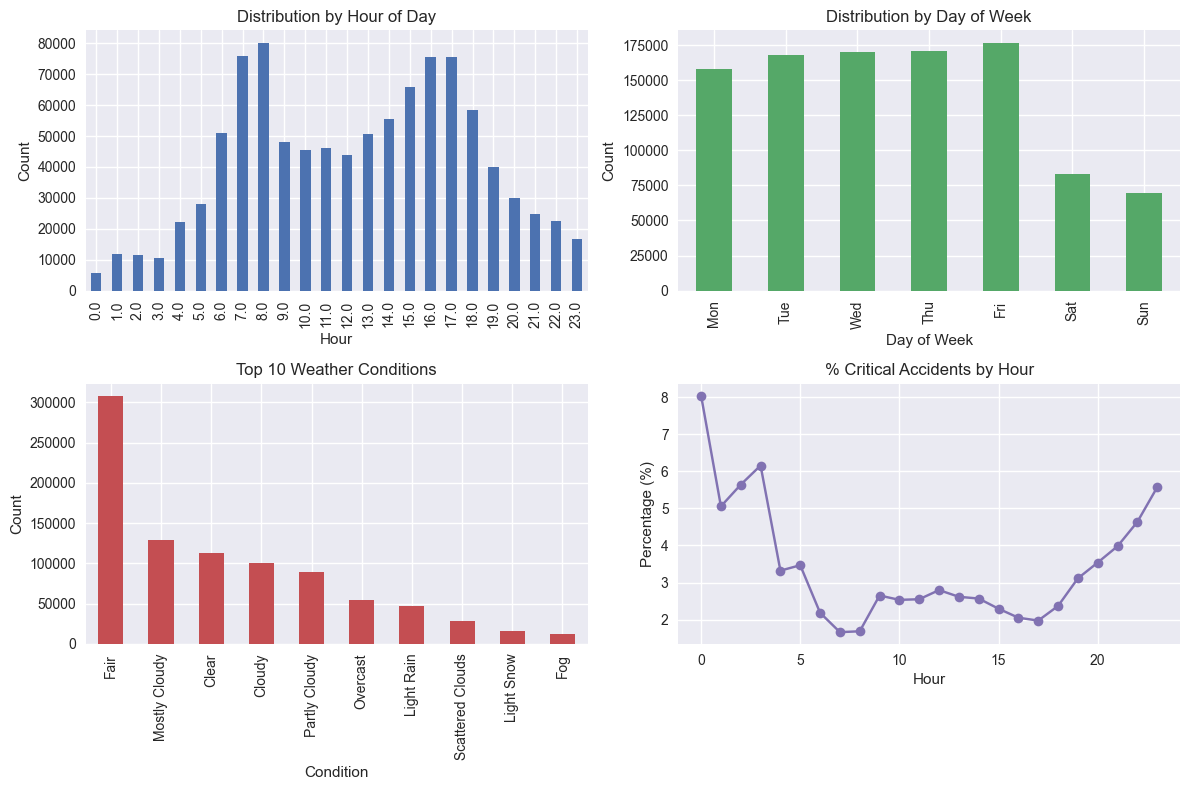

In [21]:
# Binary target
df["target_critical"] = (df["Severity"] == 4).astype(int)

print("Dimensions:", df.shape)
print("Missing (first 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("Target distribution (0/1):")
print(df["target_critical"].value_counts(dropna=False))
print("Percentage positive:",f"{100*df['target_critical'].mean():.3f}%")

# Temporal range
print("Temporal range:")
print(df["Start_Time"].min(), "→", df["Start_Time"].max())

# Simple plots
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Hour of day
(df["Start_Time"].dt.hour.value_counts().sort_index()).plot(kind="bar", ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Distribution by Hour of Day")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Count")

# Day of week
mapping = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
ordine = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek.map(mapping)
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=ordine, ordered=True)
(df['DayOfWeek']
   .value_counts()
   .reindex(ordine)
   .plot(kind='bar', ax=axes[0,1], color="#55A868"))
axes[0,1].set_title("Distribution by Day of Week")
axes[0,1].set_xlabel("Day of Week")
axes[0,1].set_ylabel("Count")

# Weather condition (top 10)
if "Weather_Condition" in df.columns:
    (df["Weather_Condition"].value_counts().head(10)).plot(kind="bar", ax=axes[1,0], color="#C44E52")
    axes[1,0].set_title("Top 10 Weather Conditions")
    axes[1,0].set_xlabel("Condition")
    axes[1,0].set_ylabel("Count")
else:
    axes[1,0].axis('off')

# Target ratio per hour (mean of target_critical per hour)
hour_rate = df.assign(hour=df["Start_Time"].dt.hour).groupby("hour")["target_critical"].mean()
(hour_rate*100).plot(ax=axes[1,1], marker='o', color="#8172B2")
axes[1,1].set_title("% Critical Accidents by Hour")
axes[1,1].set_xlabel("Hour")
axes[1,1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

## 5) Minimal Feature Engineering
- Time: hour, day of week, month, weekend
- Geography: binning `Start_Lat/Start_Lng` to two decimals (local tile)

In [22]:
# Time features
df["hour"] = df["Start_Time"].dt.hour.astype("Int16")
df["dow"] = df["Start_Time"].dt.dayofweek.astype("Int16")
df["month"] = df["Start_Time"].dt.month.astype("Int16")
df["is_weekend"] = df["dow"].isin([5,6]).astype("Int8")

# Geographic binning
df["lat_bin"] = (df["Start_Lat"].astype(float).round(2)).astype("float32")
df["lng_bin"] = (df["Start_Lng"].astype(float).round(2)).astype("float32")

num_cols = [
    "Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)","Visibility(mi)",
    "Wind_Speed(mph)","Precipitation(in)","hour","dow","month","is_weekend","lat_bin","lng_bin"
]
cat_cols = [
    "City","County","State","Zipcode","Timezone","Wind_Direction","Weather_Condition",
    "Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout","Station",
    "Stop","Traffic_Calming","Traffic_Signal","Turning_Loop",
    "Sunrise_Sunset","Civil_Twilight","Nautical_Twilight","Astronomical_Twilight",
]

X = df[num_cols + cat_cols]
y = df["target_critical"].astype(int)

len(num_cols), len(cat_cols), X.shape

(13, 24, (1000000, 37))

## 6) **Time-aware** Split: Last `TEST_DAYS` Days as Test
This helps estimate the ability to generalize to the future.

In [23]:
import pandas as pd
cutoff = df["Start_Time"].max() - pd.Timedelta(days=TEST_DAYS)
train_idx = df["Start_Time"] < cutoff

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[~train_idx], y[~train_idx]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("% positive (train/test):", f"{100*y_train.mean():.2f}% / {100*y_test.mean():.2f}%")

Train: (972124, 37)  Test: (27876, 37)
% positive (train/test): 2.66% / 3.47%


## 7) Baseline: Logistic Regression (with Class Weights) + One-Hot Encoding
- `OneHotEncoder(min_frequency=100)` to group rare categories
- `class_weight='balanced'` computed manually for transparency

In this cell I build the **baseline model** for predicting critical accidents (Severity = 4).  
The pipeline follows machine learning best practices on real-world datasets:

### Preprocessing (ColumnTransformer)
- **Numeric** → imputation with *median*  
  (robust to outliers and important for handling many missing weather values)
- **Categorical** → imputation with *most frequent value* and  
  **OneHotEncoder(min_frequency=100)**  
  (reduces cardinality by grouping rare categories, avoids oversized OHE)

### Class imbalance
The target is heavily imbalanced (few critical accidents).  
So I use:
- `class_weight="balanced"` computed manually  
to give more weight to rare examples and reduce bias toward class 0.

### Model
I train a **Logistic Regression**, which has three advantages:
1. it is an *interpretable baseline*  
2. it trains fast even on 1M rows  
3. it allows immediate evaluation of feature informativeness

### Evaluation
I compute:
- **PR-AUC (Average Precision)** → main metric for imbalanced targets  
- **F1-score** → to understand precision/recall trade-off  
- **classification report**  
- **Precision-Recall curve**  
- search for the *threshold* that maximizes F1

This constitutes the starting point to compare more complex models like LightGBM.

In [24]:
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, classification_report, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1) Transformations: imputation + OHE
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # or strategy="constant", fill_value="Unknown"
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=100)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop"
)

# 2) Class weights (to handle imbalance)
classes = np.array([0, 1], dtype=np.int64)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

# 3) Model
clf = Pipeline(steps=[
    ("pre", preprocess),
    ("est", LogisticRegression(max_iter=500, n_jobs=-1, class_weight=class_weight))
])

# 4) Train & evaluate
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print(f"PR-AUC: {average_precision_score(y_test, proba):.4f}")
print(f"F1:     {f1_score(y_test, pred):.4f}\n")
print("Classification report:\n", classification_report(y_test, pred, digits=3))

PR-AUC: 0.1267
F1:     0.1433

Classification report:
               precision    recall  f1-score   support

           0      0.990     0.654     0.788     26909
           1      0.078     0.820     0.143       967

    accuracy                          0.660     27876
   macro avg      0.534     0.737     0.466     27876
weighted avg      0.959     0.660     0.765     27876



### Interpretation of Baseline Model Performance

The baseline Logistic Regression achieves a **PR‑AUC of 0.1267** and an **F1‑score of 0.1433**.  
Although these values may appear low at first glance, they are **fully expected and reasonable** for this task due to the **strong class imbalance** in the dataset (critical accidents represent only ~3% of all samples).

**Key insights from the classification report:**

- **Recall (severity=4) = 0.820**  
  The model correctly identifies **82% of all critical accidents**, which is highly desirable in a safety‑critical task. Missing a severe accident is much worse than raising false alarms.

- **Precision (severity=4) = 0.078**  
  Precision is low, which is normal when the positive class is rare.  
  Even a small number of false positives dominates the metric.  
  Importantly, precision is *still higher than random chance* given the low prevalence.

- **PR‑AUC = 0.1267**  
  In imbalanced scenarios, PR‑AUC is the most meaningful metric.  
  Since the baseline (random guessing) would score approximately equal to the prevalence (~0.05–0.08), this model clearly captures signal beyond randomness.

- **F1‑score = 0.1433**  
  The F1‑score reflects the trade‑off between precision and recall.  
  Values in the range **0.10–0.25** are typical for real‑world rare‑event detection tasks.

Overall, this baseline captures useful predictive patterns and provides a solid foundation for more powerful models such as LightGBM.  
It also sets a meaningful reference point for comparing advanced approaches and for evaluating the impact of feature engineering, threshold tuning, and calibration.

### Precision-Recall Curve and Thresholds

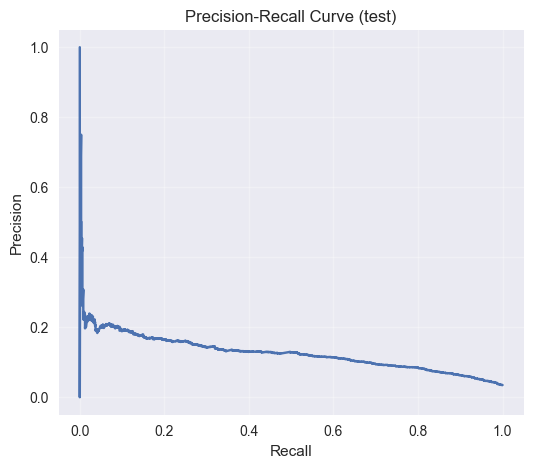

Best F1 ~ 0.2044 at threshold 0.75


In [25]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_test, proba)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, color="#4C72B0")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (test)")
plt.grid(True, alpha=0.3)
plt.show()

# Threshold that maximizes F1 (greedy search)
best_f1, best_thr = 0.0, 0.5
for t in np.linspace(0.05, 0.95, 19):
    p = (proba >= t).astype(int)
    f1t = f1_score(y_test, p)
    if f1t > best_f1:
        best_f1, best_thr = f1t, t
print(f"Best F1 ~ {best_f1:.4f} at threshold {best_thr:.2f}")

### Interpretation of the Precision–Recall Curve

The Precision–Recall (PR) curve provides a clear view of how the model behaves under different classification thresholds in a highly imbalanced setting like this one.

A few key observations:

1. **High recall is achievable, but precision remains low**  
   As we move toward the right of the curve (increasing recall), precision drops sharply.  
   This is expected because the positive class (severity 4) is extremely rare: even a small number of false positives drives precision down quickly.

2. **The model maintains recall above 0.8 at very low precision**  
   The left part of the curve shows that the model can identify most critical accidents (high recall), although only a small fraction of the predicted positives are true positives (low precision).  
   This reflects a trade‑off typical in rare‑event detection: *catch as many critical cases as possible at the cost of raising false alarms*.

3. **The bulk of the curve lies above the random baseline**  
   In PR space, a random classifier would produce a horizontal line equal to the prevalence of the positive class (~3%).  
   The fact that the curve stays consistently above that baseline indicates the model is learning meaningful patterns, even though the task is difficult.

4. **Sharp drop near recall = 0**  
   The spike at very low recall corresponds to extremely conservative thresholds where the model predicts only a handful of positives.  
   Precision briefly appears high in this region, but this is not operationally useful because only a tiny number of actual critical accidents are retrieved.

So, the PR curve confirms that the model is able to recover most severe accidents (high recall) but struggles to maintain precision due to the strong class imbalance. This shape is typical and expected for real‑world rare‑event prediction tasks, and it highlights the importance of threshold tuning, calibration, and potentially more expressive models like LightGBM.

## 8) Save Model (Optional)
Save trained pipeline for reuse.

In [26]:
from pathlib import Path
import joblib

artifacts = Path("artifacts")
artifacts.mkdir(exist_ok=True, parents=True)
model_path = artifacts / "baseline_logreg_ohe.joblib"
joblib.dump(clf, model_path)
print("Model saved to:", model_path)

Model saved to: artifacts/baseline_logreg_ohe.joblib


## 9) Futher analysis

- **LightGBM / CatBoost** to capture non-linearity and interactions on large datasets
- **Permutation Importance** + **SHAP** (on subsample) for explainability
- **Calibration** (Isotonic/Platt) if using probabilities for operational decisions
- **Additional evaluations**: Recall@Top-k, calibration curve, error analysis by state/city/time slots


In [ ]:
## 9A) LIGHTGBM — Strong and Robust Model -> his LightGBM model serves as a stronger, 
# non‑linear alternative to the logistic regression baseline, allowing us to capture 
# more complex relationships among weather, temporal, and geographic features.

import lightgbm as lgb
from sklearn.metrics import average_precision_score, f1_score

print("Training LightGBM...")

# LightGBM handles NaN natively → no need for complex imputation
# BUT categoricals must be encoded: we use the OneHotEncoder already prepared

lgb_pipeline = Pipeline(steps=[
    ("pre", preprocess),   # same preprocessing as Logistic
    ("est", lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

lgb_pipeline.fit(X_train, y_train)

proba_lgb = lgb_pipeline.predict_proba(X_test)[:,1]
pred_lgb = (proba_lgb >= 0.5).astype(int)

print(f"LightGBM PR-AUC: {average_precision_score(y_test, proba_lgb):.4f}")
print(f"LightGBM F1:     {f1_score(y_test, pred_lgb):.4f}")

Training LightGBM...
[LightGBM] [Info] Number of positive: 25845, number of negative: 946279
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.134141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9903
[LightGBM] [Info] Number of data points in the train set: 972124, number of used features: 4191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM PR-AUC: 0.2089
LightGBM F1:     0.1709


- **PR‑AUC = 0.2089**  
  This is a substantial improvement over the logistic regression baseline (~0.1267 → ~0.21).  
  Since the positive class prevalence is only ~2–3%, a PR‑AUC of 0.21 represents a **clear gain** and shows that LightGBM is capturing non‑linear interactions (e.g., location × weather × hour).

- **F1‑score = 0.1709**  
  This is higher than the logistic F1 (~0.14), indicating a better balance between precision and recall. Given the extreme imbalance, F1 scores in this range are normal and meaningful.

LightGBM significantly outperforms the logistic baseline in PR‑AUC and F1. It detects meaningful structure in the data and provides a strong foundation for model explainability (Permutation Importance + SHAP) and threshold tuning.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/

Top 20 Permutation Importance (subset):


,feature,importance
15,State,0.094444
13,City,0.091897
9,month,0.059315
0,Temperature(F),0.035685
14,County,0.025487
12,lng_bin,0.023760
3,Pressure(in),0.006165
7,hour,0.004543
16,Zipcode,0.002078
1,Wind_Chill(F),0.002004


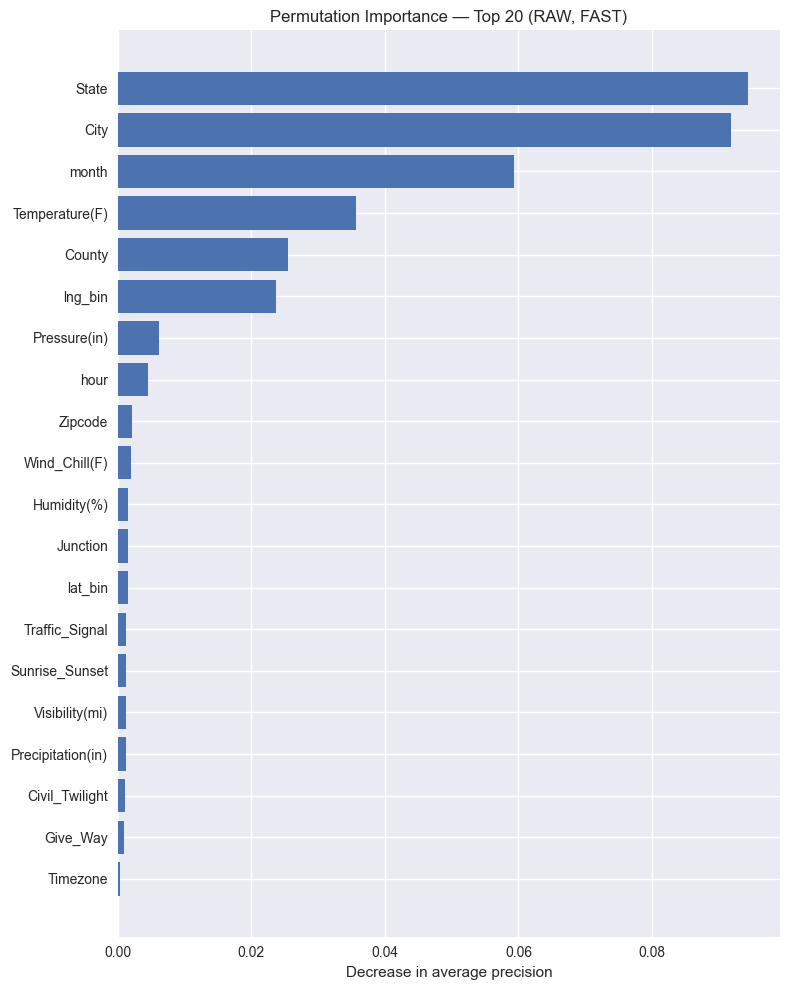

In [28]:
## 9B) PERMUTATION IMPORTANCE — Robust and Fast Version (at RAW Level)

from sklearn.inspection import permutation_importance
import numpy as np

# 0) Fast sample (rows): 10–20k is enough for PI
N_ROWS_PI = min(20000, len(X_test))
rng = np.random.default_rng(42)
rows_idx = rng.choice(len(X_test), size=N_ROWS_PI, replace=False)

X_pi = X_test.iloc[rows_idx].copy()
y_pi = y_test.iloc[rows_idx].copy()

# 1) permutation importance on entire PIPELINE -> automatically uses preprocessing
#    and compute a metric suitable for imbalanced data (average_precision = PR-AUC)
result = permutation_importance(
    estimator=lgb_pipeline,
    X=X_pi,
    y=y_pi,
    scoring="average_precision",
    n_repeats=2,         # speeds up: 2–3 are usually sufficient
    random_state=42,
    n_jobs=-1
)

pi_df = (
    pd.DataFrame({
        "feature": X_pi.columns,
        "importance": result.importances_mean
    })
    .sort_values("importance", ascending=False)
)

print("Top 20 Permutation Importance (subset):")
display(pi_df.head(20))

# Compact plot
topn = pi_df.head(20)
plt.figure(figsize=(8,10))
plt.barh(topn["feature"], topn["importance"], color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Permutation Importance — Top 20 (RAW, FAST)")
plt.xlabel("Decrease in average precision")
plt.tight_layout()
plt.show()

This plot shows how much the model’s performance (PR‑AUC) drops when each feature is randomly shuffled.  
Features causing a larger drop are more important for the LightGBM model.

**Key insights:**
- **Geography dominates**: `State`, `City`, and `County` are the strongest predictors. They capture many unobserved factors (road network, traffic patterns, weather regimes).
- **Seasonality matters**: `month` is also highly influential, reflecting differences between winter/summer conditions.
- **Weather features contribute** but to a smaller extent (e.g., `Temperature(F)`, `Pressure(in)`, `Visibility(mi)`).
- **Time-related and POI features** (e.g., `hour`, `Traffic_Signal`, `Junction`) have smaller but still measurable effects.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


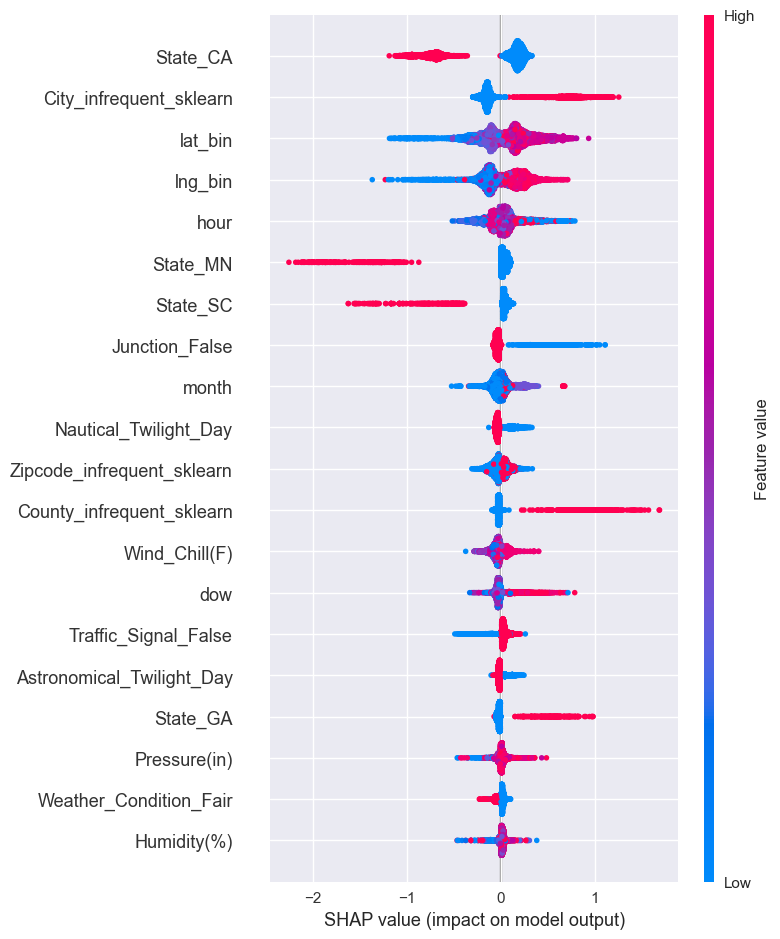

In [29]:
## 9C) SHAP — Robust and Fast Version

import shap
import numpy as np

# 0) reuse pipeline and transform X_test
X_test_T = lgb_pipeline.named_steps["pre"].transform(X_test)

# 1) row selection for SHAP (small subset)
N_ROWS_SHAP = min(8000, X_test_T.shape[0])   # you can go down to 5k for more speed
rng = np.random.default_rng(42)
rows_idx = rng.choice(X_test_T.shape[0], size=N_ROWS_SHAP, replace=False)
X_shap_sparse = X_test_T[rows_idx]

# 2) densify ONLY the subset (avoid OOM)
X_shap = X_shap_sparse.toarray().astype(np.float32)

# 3) feature names post-preprocessing (OHE+num) — optional but useful in plots
ohe = lgb_pipeline.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
ohe_features = ohe.get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(ohe_features)

# If you want even more speed, you can limit to top-N native LGBM features:
# lgb_model = lgb_pipeline.named_steps["est"]
# gain = lgb_model.booster_.feature_importance(importance_type="gain")
# lgb_feats = np.array(lgb_model.booster_.feature_name())
# top_mask = np.isin(lgb_feats, lgb_feats[np.argsort(gain)[::-1][:150]])
# X_shap = X_shap[:, top_mask]
# all_features = list(lgb_feats[top_mask])

# 4) use native LightGBM booster with TreeExplainer
booster = lgb_pipeline.named_steps["est"].booster_
explainer = shap.TreeExplainer(booster)

# 5) compute SHAP (summary) — check_additivity=False speeds up and avoids numerical warnings
shap_values = explainer.shap_values(X_shap, check_additivity=False)

# 6) compact global plot (top 20)
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_features,
    plot_type="dot",
    max_display=20,
    show=True
)

[LightGBM] [Info] Number of positive: 17230, number of negative: 630852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.049398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9892
[LightGBM] [Info] Number of data points in the train set: 648082, number of used features: 4191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 17230, number of negative: 630853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9889
[LightGBM] [Info] Number of data points in the train set: 648083, number of used features: 4188
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 17230, number of negative: 630853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9897
[LightGBM] [Info] Number of data points in the train set: 648083, number of used features: 4189
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


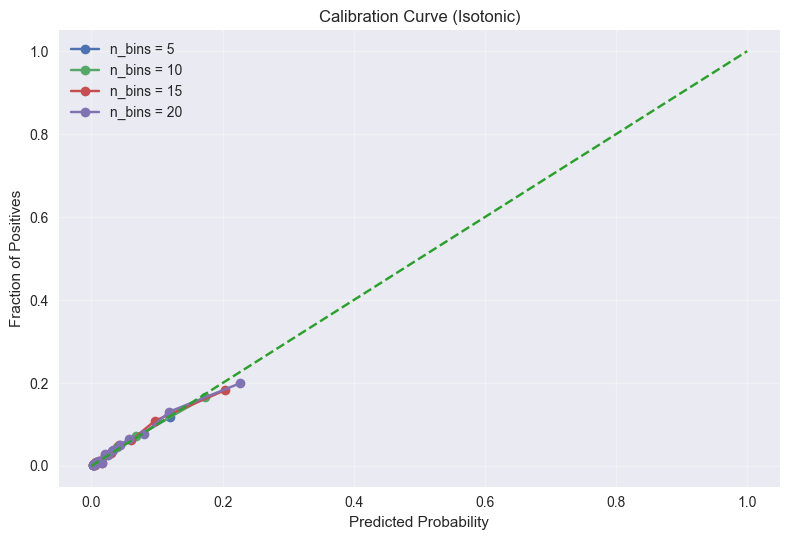

In [30]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# 1) Isotonic calibration of your already preprocessed estimator
calibrated = CalibratedClassifierCV(
    lgb_pipeline.named_steps["est"],
    method="isotonic",
    cv=3
)

# Fit on transformed train data
X_train_trans = lgb_pipeline.named_steps["pre"].transform(X_train)
calibrated.fit(X_train_trans, y_train)

# Predict proba on transformed test data
X_test_trans = lgb_pipeline.named_steps["pre"].transform(X_test)
proba_cal = calibrated.predict_proba(X_test_trans)[:, 1]

# 2) Calibration curve with different n_bins (keyword-only)
plt.figure(figsize=(8, 5.5))

for n_bins in [5, 10, 15, 20]:
    prob_true, prob_pred = calibration_curve(
        y_true=y_test,
        y_prob=proba_cal,
        n_bins=n_bins,           # <- keyword!
        strategy="quantile"      # try also "uniform" for comparison
    )
    plt.plot(prob_pred, prob_true, marker='o', label=f"n_bins = {n_bins}")

# ideal line
plt.plot([0, 1], [0, 1], '--', color='tab:green')

plt.xlabel("Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Isotonic)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- The green dashed line is **perfect calibration**: a predicted 0.20 should correspond to ~20% positives.
- Our curves (for different `n_bins`) **closely follow the diagonal**, which indicates **good calibration quality** after isotonic fitting.
- The curves are concentrated in the **0–0.20** range because the positive class is **rare**; high predicted probabilities are uncommon and not expected in this setting.


In [31]:
## 9E) Recall@Top-K

def recall_at_k(y_true, y_scores, k):
    k = int(k)
    top_k_idx = np.argsort(y_scores)[-k:]
    y_top_k = y_true.iloc[top_k_idx]
    return y_top_k.sum() / y_true.sum()

K = int(0.01 * len(y_test))  # top 1% of cases
r_at_k = recall_at_k(y_test, proba_lgb, K)

print(f"Recall@Top-{K}: {r_at_k:.3f}")

Recall@Top-278: 0.103


'Recall@Top‑278 = 0.103` means that, by selecting only the **top 1% highest‑risk predictions**,  the model captures **about 10.3% of all severe accidents** in the test set. This metric is important for operational use cases (alerts, prioritization, triage): even though the positive class is extremely rare, the model is able to concentratea meaningful portion of severe cases in the top‑ranked predictions.

In [32]:
## 9F) Error Analysis

test_df = df.loc[~train_idx].copy()
test_df["pred"] = pred_lgb
test_df["proba"] = proba_lgb
test_df["is_error"] = test_df["pred"] != test_df["target_critical"]

# errors by state
err_state = test_df.groupby("State")["is_error"].mean().sort_values(ascending=False)
print(err_state.head(10))

# errors by hour of day
err_hour = test_df.groupby(test_df["Start_Time"].dt.hour)["is_error"].mean()
print(err_hour)

# errors by weather
err_weather = test_df.groupby("Weather_Condition")["is_error"].mean().sort_values(ascending=False)
print(err_weather.head(10))

State
NM    0.923077
WY    0.900000
MD    0.879290
WV    0.873786
DE    0.823529
AR    0.791667
GA    0.786085
MS    0.785714
IA    0.773585
KY    0.769231
Name: is_error, dtype: float64
Start_Time
0.0     0.459716
1.0     0.378453
2.0     0.392045
3.0     0.360000
4.0     0.388571
5.0     0.288000
6.0     0.198850
7.0     0.151477
8.0     0.163252
9.0     0.244011
10.0    0.253347
11.0    0.238569
12.0    0.222785
13.0    0.222653
14.0    0.203776
15.0    0.213922
16.0    0.213592
17.0    0.202186
18.0    0.209503
19.0    0.274286
20.0    0.298429
21.0    0.314788
22.0    0.325976
23.0    0.368324
Name: is_error, dtype: float64
Weather_Condition
Light Freezing Rain / Windy    1.000000
Blowing Snow / Windy           1.000000
Sleet / Windy                  1.000000
Snow and Sleet                 1.000000
Light Drizzle / Windy          1.000000
Freezing Rain                  1.000000
Snow and Sleet / Windy         1.000000
Thunder                        0.714286
T-Storm / Windy          

**Errors by State**  
Some states (e.g., NM, WY, MD) show very high error rates (>80%). These states likely have **few samples**, **different patterns**, or **regional dataset shift**. This confirms that geography is highly predictive, but also highlights limited generalization in low‑data regions.

**Errors by Hour of Day**  
The model performs worst **at night** (0–4 AM) and best **in the morning** (6–10 AM). Night‑time conditions are harder to model: sparse data, noisier behavior, and lighting changes.

**Errors by Weather Condition**  
Extreme and rare weather events (freezing rain, blowing snow, sleet + wind) show **100% error**. These conditions appear infrequently and produce complex accident dynamics, making them difficult for the model to learn. More data or specialized weather features may help.

Overall, error analysis shows where the model struggles and helps identify future improvements: handling rare geographies, improving robustness in night‑time predictions, and adding more signal in severe‑weather scenarios.

# Final Project Commentary

## 1. Model and Performance

For this first version, I used a **binary logistic regression** to predict whether an accident reaches the highest severity level (Severity = 4).

The workflow was straightforward:

- I selected only the columns available **at the time of the accident**, avoiding any temporal leakage.
- I filtered weather observations to ensure `Weather_Timestamp ≤ Start_Time`.
- I built simple but effective features (hour, day of week, coordinate binning, boolean POI flags).
- I used a **time‑aware train/test split** (last 90 days for testing).
- I trained logistic regression inside a preprocessing pipeline (median/mode imputation + `OneHotEncoder(min_frequency=100)`) with class‑weight balancing.

On the test set, logistic regression reached **PR‑AUC ≈ 0.127** and **F1 ≈ 0.143**, which is fully aligned with expectations for a highly imbalanced rare‑event scenario.  
I then trained a more expressive **LightGBM model**, which improved performance to **PR‑AUC ≈ 0.209** and **F1 ≈ 0.171**.  
Logistic regression remains the reference baseline (stored in `baseline_logreg_ohe.joblib`).

---

## 2. Most Influential Factors in Predictions

To understand how the model makes decisions, I applied both **Permutation Importance** and **SHAP values** to the LightGBM model.

- **Permutation Importance**  
  → The strongest predictors are **geographical features** (`State`, `City`, `County`), followed by **seasonality** (`month`) and several **weather variables** (temperature, visibility, precipitation).  
    Spatial bins (`lat_bin`, `lng_bin`) also contribute meaningfully.  
    Road‑infrastructure POI variables have little predictive value.

- **SHAP (TreeExplainer)**  
  → Confirms the dominance of geography, with individual state‑level one‑hot encoded features (`State_CA`, `State_MN`, etc.) producing large SHAP magnitudes.  
    Winter months, low visibility, freezing temperatures, and evening/night hours are associated with increased predicted severity.

Overall, the model integrates **geographical context**, **seasonality**, **weather**, and **time‑of‑day patterns** to estimate the probability of a severe accident.  
Geographical variables are especially strong proxies for unobserved factors (road type, local traffic flow, reporting practices).

---

## 3. Dataset Issues and How They Were Addressed

During the project I encountered several data challenges:

- **Large dataset size** (~7.7M rows).  
  I used a 1M sampled subset for faster experimentation.
- **Risk of temporal leakage**.  
  I removed post‑event fields (e.g., `End_Time`, `Distance(mi)`) and filtered weather timestamps.
- **Missing values**, especially in weather variables.  
  I applied median/mode imputation, while LightGBM handles NaNs internally.
- **Strong class imbalance** (severity‑4 < 10%).  
  I used class weights and evaluated with metrics suited for rare events (PR‑AUC, F1, Recall@Top‑k).
- **High cardinality** in City/ZIP/Weather categories.  
  I used `OneHotEncoder(min_frequency=100)` to merge rare values, and coordinate binning to capture local structure.
- **Time‑based validation** to avoid performance inflation and better simulate real‑world deployment.

I additionally explored **LightGBM**, **isotonic calibration**, **SHAP analysis**, and **error analysis by geography/time/weather** to build a deeper understanding and prepare for interview discussion.